# 03 RADAR Velocity Analysis

RADAR velocity-related information analysis and preparation of RADAR-side information-acquisition metrics.

## 1. Purpose and Scope

This notebook analyses the velocity-related information provided by TruckScenes RADAR and prepares reusable RADAR measurements for later comparison with the annotation-derived vehicle reference velocity.

The annotation reference velocity developed in `02_Annotation_Reference_Velocity.ipynb` is reused without recalculation. The primary reference remains the 2D vehicle speed, and the same speed ranges defined in Notebook 02 will be retained.

This notebook focuses on:

* validating RADAR velocity-related data;
* associating RADAR returns with annotated target vehicles;
* deriving target-level RADAR velocity information;
* analysing RADAR information under different reference-speed conditions; and
* measuring the availability of usable RADAR velocity information.

The RADAR fields `vrel_x`, `vrel_y`, and `vrel_z` contain point-level relative velocity information and are not treated as equivalent to annotation-derived absolute vehicle velocity.

LiDAR analysis and the final RADAR–LiDAR comparison are outside the scope of this notebook.


## 2. Validate RADAR Velocity Data

Before loading RADAR measurements, the PCD structure is checked to confirm the availability and storage format of the velocity-related fields.

In [1]:
from pathlib import Path
import sys

import pandas as pd


%load_ext autoreload
%autoreload 2


PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.config import SAMPLES_ROOT
from src.data_io import read_pcd_header
from src.radar_velocity import load_radar_points

In [2]:
records = []

for sensor_folder in sorted(SAMPLES_ROOT.iterdir()):

    if not sensor_folder.is_dir():
        continue

    if not sensor_folder.name.startswith("RADAR"):
        continue

    pcd_file = next(
        iter(sorted(sensor_folder.glob("*.pcd"))),
        None,
    )

    if pcd_file is None:
        continue

    header = read_pcd_header(pcd_file)

    fields = header["FIELDS"].split()

    records.append({
        "Sensor": sensor_folder.name,
        "Fields": header["FIELDS"],
        "Velocity Fields Present": all(
            field in fields
            for field in ["vrel_x", "vrel_y", "vrel_z"]
        ),
        "Size": header["SIZE"],
        "Type": header["TYPE"],
        "Data Format": header["DATA"],
        "Points": header["POINTS"],
    })


radar_pcd_check = pd.DataFrame(records)

display(radar_pcd_check)

,Sensor,Fields,Velocity Fields Present,Size,Type,Data Format,Points
0,RADAR_LEFT_BACK,x y z vrel_x vrel_y vrel_z rcs,True,4 4 4 4 4 4 4,F F F F F F F,binary,677
1,RADAR_LEFT_FRONT,x y z vrel_x vrel_y vrel_z rcs,True,4 4 4 4 4 4 4,F F F F F F F,binary,612
2,RADAR_LEFT_SIDE,x y z vrel_x vrel_y vrel_z rcs,True,4 4 4 4 4 4 4,F F F F F F F,binary,416
3,RADAR_RIGHT_BACK,x y z vrel_x vrel_y vrel_z rcs,True,4 4 4 4 4 4 4,F F F F F F F,binary,430
4,RADAR_RIGHT_FRONT,x y z vrel_x vrel_y vrel_z rcs,True,4 4 4 4 4 4 4,F F F F F F F,binary,556
5,RADAR_RIGHT_SIDE,x y z vrel_x vrel_y vrel_z rcs,True,4 4 4 4 4 4 4,F F F F F F F,binary,290


All six RADAR channels contain the same seven fields:

`x`, `y`, `z`, `vrel_x`, `vrel_y`, `vrel_z`, and `rcs`.

The fields are stored as 4-byte floating-point values in binary PCD files. The expected velocity-related fields are therefore available consistently across the inspected RADAR channels.

In [3]:
example_radar_folder = next(
    folder
    for folder in sorted(SAMPLES_ROOT.iterdir())
    if folder.is_dir()
    and folder.name.startswith("RADAR")
)

example_radar_file = next(
    iter(sorted(example_radar_folder.glob("*.pcd")))
)

radar_points_df = load_radar_points(
    example_radar_file
)


print("Sensor:", example_radar_folder.name)
print("File:", example_radar_file.name)
print("Shape:", radar_points_df.shape)
print("Columns:", radar_points_df.columns.tolist())

print("\nMissing values:")
display(
    radar_points_df
    .isna()
    .sum()
    .to_frame("Missing")
)

display(radar_points_df.head())

display(
    radar_points_df[
        [
            "vrel_x",
            "vrel_y",
            "vrel_z",
            "rcs",
        ]
    ]
    .describe()
)

Sensor: RADAR_LEFT_BACK
File: RADAR_LEFT_BACK_1692868171703928.pcd
Shape: (677, 7)
Columns: ['x', 'y', 'z', 'vrel_x', 'vrel_y', 'vrel_z', 'rcs']

Missing values:


,Missing
x,0
y,0
z,0
vrel_x,0
vrel_y,0
vrel_z,0
rcs,0


,x,y,z,vrel_x,vrel_y,vrel_z,rcs
0,1.909485,1.751730,0.587254,-0.008175,-0.007499,-0.002514,-10.0
1,2.723978,2.486560,0.047946,-0.013088,-0.011947,-0.000230,-6.0
2,3.829269,3.511275,0.050495,-0.022772,-0.020881,-0.000300,-12.0
3,3.849017,-4.550885,-0.926338,0.033594,-0.039720,-0.008085,-6.0
4,3.884814,-4.552763,-0.855817,0.029689,-0.034793,-0.006540,-8.0


,vrel_x,vrel_y,vrel_z,rcs
count,677.000000,677.000000,677.000000,677.000000
mean,16.999071,4.392402,0.329087,-9.017725
std,10.212269,6.652874,1.342577,6.468838
min,-23.610424,-19.806664,-4.691231,-20.000000
25%,16.604853,-0.369041,-0.275933,-13.000000
50%,20.325529,4.250233,0.187977,-10.000000
75%,20.912863,8.685211,1.242984,-6.000000
max,47.979935,26.827625,4.745102,27.000000


The example RADAR PCD was successfully loaded as 677 point-level returns with the seven expected fields and no missing values. This validates the binary point-loading method for the inspected TruckScenes RADAR structure. Physical interpretation of the `vrel_*` values is considered separately from the file-reading validation.

## 3. Align and Associate RADAR with Target Vehicles

RADAR observations use `sample_data.timestamp`, while the annotation reference velocity is based on annotated sample keyframes. The temporal relationship is therefore checked before target association.

Target association is first validated using keyframe RADAR observations. Annotation boxes are transformed from the global coordinate system into each RADAR sensor frame and RADAR returns inside the transformed 3D boxes are identified.

The same target-vehicle definition used in Notebook 02 is retained: `vehicle.*` categories are included and `vehicle.ego_trailer` is excluded.

In [4]:
from src.config import METADATA_ROOT
from src.data_io import load_json
from src.sensor_observation import build_sensor_data_df


sensor_data_df = build_sensor_data_df()

radar_observation_df = (
    sensor_data_df[
        sensor_data_df["Modality"] == "RADAR"
    ]
    .copy()
)

samples = load_json(
    METADATA_ROOT / "sample.json"
)

sample_data = load_json(
    METADATA_ROOT / "sample_data.json"
)

sample_timestamp_lookup = {
    record["token"]: record["timestamp"]
    for record in samples
}

sample_data_lookup = {
    record["token"]: record
    for record in sample_data
}

radar_observation_df["Sample Timestamp"] = (
    radar_observation_df["Sample Token"]
    .map(sample_timestamp_lookup)
)

radar_observation_df["Is Key Frame"] = (
    radar_observation_df["Token"]
    .map(
        lambda token:
        sample_data_lookup[token]["is_key_frame"]
    )
)

radar_observation_df["Sample Offset ms"] = (
    radar_observation_df["Timestamp"]
    - radar_observation_df["Sample Timestamp"]
) / 1_000

keyframe_radar = radar_observation_df[
    radar_observation_df["Is Key Frame"]
].copy()


print("RADAR observations:", len(radar_observation_df))
print("Keyframe observations:", len(keyframe_radar))

print(
    "Median absolute keyframe offset (ms):",
    keyframe_radar["Sample Offset ms"].abs().median(),
)

print(
    "Maximum absolute keyframe offset (ms):",
    keyframe_radar["Sample Offset ms"].abs().max(),
)

RADAR observations: 23439
Keyframe observations: 2400
Median absolute keyframe offset (ms): 5.4445
Maximum absolute keyframe offset (ms): 55.836


The dataset contains 23,439 RADAR observations, including 2,400 keyframe observations. The median absolute timestamp offset between keyframe RADAR observations and their linked annotation samples is approximately 5.44 ms, with a maximum of approximately 55.84 ms.

Keyframe RADAR observations are therefore used first for target association.

In [5]:
from src.radar_velocity import (
    build_target_radar_points_df,
)


# Select one sample containing all six RADAR keyframes.
sensor_counts = (
    keyframe_radar
    .groupby("Sample Token")["Sensor"]
    .nunique()
)

example_sample_token = (
    sensor_counts[
        sensor_counts == 6
    ]
    .index[0]
)

example_radar = keyframe_radar[
    keyframe_radar["Sample Token"]
    == example_sample_token
]

example_target_points = (
    build_target_radar_points_df(
        example_radar
    )
)


annotations = load_json(
    METADATA_ROOT / "sample_annotation.json"
)

instances = load_json(
    METADATA_ROOT / "instance.json"
)

categories = load_json(
    METADATA_ROOT / "category.json"
)

instance_lookup = {
    record["token"]: record
    for record in instances
}

category_lookup = {
    record["token"]: record["name"]
    for record in categories
}


vehicle_annotations = []

for annotation in annotations:

    if annotation["sample_token"] != example_sample_token:
        continue

    instance = instance_lookup[
        annotation["instance_token"]
    ]

    category = category_lookup[
        instance["category_token"]
    ]

    if (
        category.startswith("vehicle.")
        and category != "vehicle.ego_trailer"
    ):
        vehicle_annotations.append(annotation)


metadata_counts = pd.Series(
    {
        annotation["token"]:
        annotation["num_radar_pts"]

        for annotation in vehicle_annotations
    },
    name="Metadata",
)

associated_counts = (
    example_target_points
    .groupby("annotation_token")
    .size()
    .reindex(
        metadata_counts.index,
        fill_value=0,
    )
    .rename("Associated")
)

association_check = pd.concat(
    [
        metadata_counts,
        associated_counts,
    ],
    axis=1,
)

association_check["Difference"] = (
    association_check["Associated"]
    - association_check["Metadata"]
)


print(
    "Exact matches:",
    (association_check["Difference"] == 0).sum(),
    "/",
    len(association_check),
)

print(
    "Maximum absolute difference:",
    association_check["Difference"].abs().max(),
)

Exact matches: 69 / 69
Maximum absolute difference: 0


In [6]:
target_radar_points_df = (
    build_target_radar_points_df(
        keyframe_radar
    )
)


print(
    "Associated RADAR returns:",
    len(target_radar_points_df),
)

print(
    "Vehicle annotations with RADAR returns:",
    target_radar_points_df[
        "annotation_token"
    ].nunique(),
)

print(
    "Target vehicles with RADAR returns:",
    target_radar_points_df[
        "instance_token"
    ].nunique(),
)

Associated RADAR returns: 52184
Vehicle annotations with RADAR returns: 9588
Target vehicles with RADAR returns: 639


The validated keyframe association workflow produced 52,184 target-associated RADAR returns covering 9,588 vehicle annotations from 639 unique target vehicles.

`target_radar_points_df` is the point-level RADAR dataset used in the following analysis. Each row represents one RADAR return associated with an annotated target vehicle.

## 4. Build Target-Level RADAR Velocity Information

RADAR velocity measurements are available at the individual-return level, while the annotation reference velocity is defined at the target-vehicle level.

The `vrel_x`, `vrel_y`, and `vrel_z` components from different RADAR sensors are not directly averaged because they are expressed in different sensor coordinate frames. Instead, the relative-velocity magnitude is calculated for each associated RADAR return:

\[
v_{\mathrm{rel}} = \sqrt{v_{\mathrm{rel},x}^2 + v_{\mathrm{rel},y}^2 + v_{\mathrm{rel},z}^2}
\]

This quantity is used only as a RADAR relative-velocity measurement and is not treated as the absolute vehicle speed.

Point-level measurements are then summarised for each annotated target vehicle.

In [7]:
from src.radar_velocity import build_target_radar_velocity_df


target_radar_df = build_target_radar_velocity_df(
    target_radar_points_df
)

print(
    "Target-level RADAR observations:",
    len(target_radar_df),
)

print(
    "Median RADAR returns per target:",
    target_radar_df["radar_return_count"].median(),
)

print(
    "Targets with one RADAR return:",
    (target_radar_df["radar_return_count"] == 1).sum(),
)

Target-level RADAR observations: 9588
Median RADAR returns per target: 3.0
Targets with one RADAR return: 2845


The 9,588 target-level RADAR observations contain a median of three associated RADAR returns per target, while 2,845 observations contain only one return.

Because the relative-velocity magnitude is right-skewed and some targets contain very few returns, the median relative-velocity magnitude is retained as the primary target-level RADAR velocity summary. Return count and sensor count are retained separately as measures of RADAR information availability.

## 5. Analyse RADAR Information by Reference Speed Range

Target-level RADAR measurements are aligned with the annotation-derived reference velocity developed in Notebook 02.

Each RADAR target observation corresponds to an annotation keyframe. It is therefore linked to the reference-velocity interval that begins at the same annotation (`start_annotation_token`).

The RADAR relative-velocity magnitude and the annotation-derived vehicle speed remain physically different quantities. The reference speed is used here to define comparable vehicle-speed conditions rather than as a direct RADAR error target.

In [8]:
from src.annotation_velocity import (
    build_annotation_trajectory_df,
    build_annotation_pairs,
    add_time_differences,
    add_position_changes,
    add_reference_velocity,
)


annotation_trajectory_df = build_annotation_trajectory_df(
    samples,
    annotations,
    instances,
    categories,
)

reference_velocity_df = build_annotation_pairs(
    annotation_trajectory_df
)

reference_velocity_df = add_time_differences(
    reference_velocity_df
)

reference_velocity_df = add_position_changes(
    reference_velocity_df
)

reference_velocity_df = add_reference_velocity(
    reference_velocity_df
)


# Keep the same target-vehicle definition as Notebook 02.
vehicle_reference_df = reference_velocity_df[
    reference_velocity_df["category"].str.startswith("vehicle.")
    & (
        reference_velocity_df["category"]
        != "vehicle.ego_trailer"
    )
].copy()


radar_reference_df = target_radar_df.merge(
    vehicle_reference_df[
        [
            "start_annotation_token",
            "end_annotation_token",
            "dt_s",
            "speed_2d_mps",
            "speed_3d_mps",
        ]
    ],
    left_on="annotation_token",
    right_on="start_annotation_token",
    how="left",
    validate="one_to_one",
)


print(
    "RADAR target observations:",
    len(target_radar_df),
)

print(
    "Matched reference intervals:",
    radar_reference_df[
        "speed_2d_mps"
    ].notna().sum(),
)

print(
    "Unmatched observations:",
    radar_reference_df[
        "speed_2d_mps"
    ].isna().sum(),
)

print(
    "Reference match rate:",
    round(
        radar_reference_df[
            "speed_2d_mps"
        ].notna().mean() * 100,
        2,
    ),
    "%",
)

RADAR target observations: 9588
Matched reference intervals: 9280
Unmatched observations: 308
Reference match rate: 96.79 %


In [9]:
unmatched_df = radar_reference_df[
    radar_reference_df["speed_2d_mps"].isna()
]

trajectory_last_tokens = set(
    annotation_trajectory_df.loc[
        annotation_trajectory_df["next"] == "",
        "annotation_token",
    ]
)

last_annotation_count = (
    unmatched_df["annotation_token"]
    .isin(trajectory_last_tokens)
    .sum()
)

print("Unmatched observations:", len(unmatched_df))
print(
    "Unmatched because annotation is trajectory end:",
    last_annotation_count,
)
print(
    "Other unmatched observations:",
    len(unmatched_df) - last_annotation_count,
)

Unmatched observations: 308
Unmatched because annotation is trajectory end: 308
Other unmatched observations: 0


Of the 9,588 RADAR target observations, 9,280 (96.79%) can be linked to an annotation-derived reference-velocity interval.

All 308 unmatched observations correspond to the final annotation of an object trajectory, where no subsequent annotation exists to define a reference-velocity interval. These observations are retained in the RADAR dataset but are not used in reference-speed-conditioned analysis.

In [10]:
speed_bins = [
    0, 10, 20, 30, 40, 50, 60,
    70, 80, 90, 100, 110, float("inf"),
]

speed_labels = [
    "0–<10",
    "10–<20",
    "20–<30",
    "30–<40",
    "40–<50",
    "50–<60",
    "60–<70",
    "70–<80",
    "80–<90",
    "90–<100",
    "100–<110",
    "≥110",
]


radar_speed_df = (
    radar_reference_df[
        radar_reference_df["speed_2d_mps"].notna()
    ]
    .copy()
)

radar_speed_df["speed_2d_kmh"] = (
    radar_speed_df["speed_2d_mps"] * 3.6
)

radar_speed_df["speed_range_kmh"] = pd.cut(
    radar_speed_df["speed_2d_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
    include_lowest=True,
)


speed_range_counts = (
    radar_speed_df["speed_range_kmh"]
    .value_counts(sort=False)
    .rename("RADAR Target Observations")
    .to_frame()
)

display(speed_range_counts)

print(
    "Unassigned speed ranges:",
    radar_speed_df["speed_range_kmh"].isna().sum(),
)

,RADAR Target Observations
speed_range_kmh,
0–<10,4345
10–<20,1292
20–<30,689
30–<40,424
40–<50,244
50–<60,218
60–<70,343
70–<80,447
80–<90,490


Unassigned speed ranges: 0


In [11]:
reference_speed_df = vehicle_reference_df.copy()

reference_speed_df["speed_2d_kmh"] = (
    reference_speed_df["speed_2d_mps"] * 3.6
)

reference_speed_df["speed_range_kmh"] = pd.cut(
    reference_speed_df["speed_2d_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
    include_lowest=True,
)


reference_counts = (
    reference_speed_df
    .groupby("speed_range_kmh", observed=False)
    .size()
    .rename("Reference Intervals")
)

radar_counts = (
    radar_speed_df
    .groupby("speed_range_kmh", observed=False)
    .size()
    .rename("RADAR Observations")
)

radar_metrics = (
    radar_speed_df
    .groupby("speed_range_kmh", observed=False)
    .agg(
        Median_Returns=("radar_return_count", "median"),
        Median_Sensors=("radar_sensor_count", "median"),
        Median_Vrel=("median_vrel_magnitude", "median"),
    )
)


radar_speed_summary = pd.concat(
    [
        reference_counts,
        radar_counts,
        radar_metrics,
    ],
    axis=1,
)

radar_speed_summary["RADAR Availability (%)"] = (
    radar_speed_summary["RADAR Observations"]
    / radar_speed_summary["Reference Intervals"]
    * 100
)

radar_speed_summary = radar_speed_summary[
    [
        "Reference Intervals",
        "RADAR Observations",
        "RADAR Availability (%)",
        "Median_Returns",
        "Median_Sensors",
        "Median_Vrel",
    ]
].round(2)

display(radar_speed_summary)

,Reference Intervals,RADAR Observations,RADAR Availability (%),Median_Returns,Median_Sensors,Median_Vrel
speed_range_kmh,,,,,,
0–<10,6870,4345,63.25,3.0,1.0,2.870000
10–<20,2028,1292,63.71,3.0,1.0,2.360000
20–<30,1211,689,56.90,3.0,1.0,1.760000
30–<40,799,424,53.07,2.0,1.0,7.370000
40–<50,510,244,47.84,2.0,1.0,11.210000
50–<60,424,218,51.42,3.0,1.0,21.030001
60–<70,542,343,63.28,4.0,1.0,22.280001
70–<80,823,447,54.31,3.0,1.0,17.910000
80–<90,797,490,61.48,4.0,1.0,15.960000


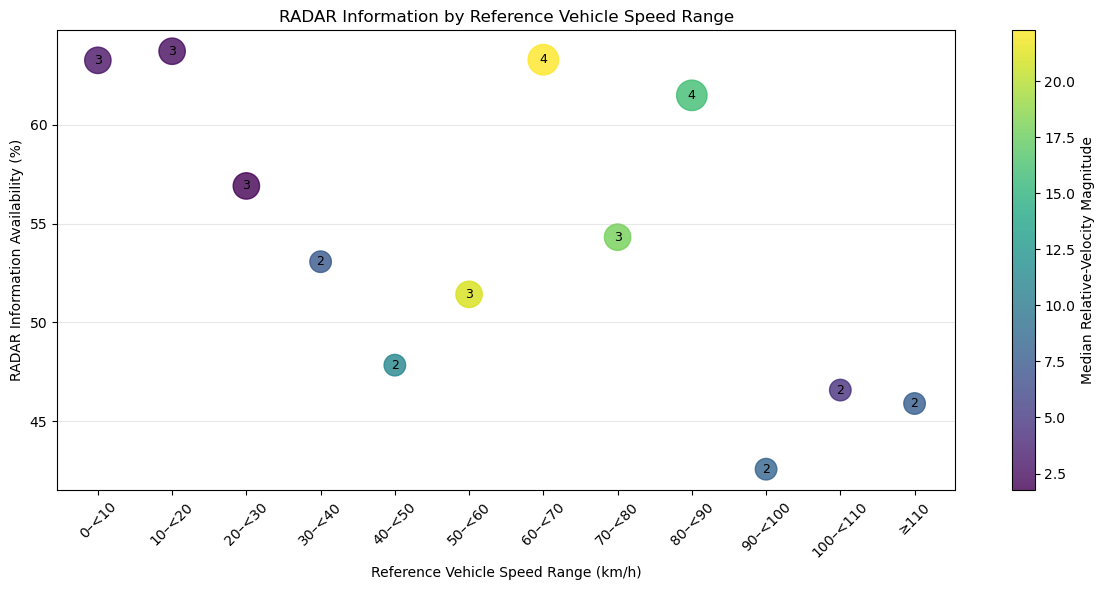

In [12]:
import matplotlib.pyplot as plt


plot_data = radar_speed_summary.reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    plot_data["speed_range_kmh"].astype(str),
    plot_data["RADAR Availability (%)"],
    s=plot_data["Median_Returns"] * 120,
    c=plot_data["Median_Vrel"],
    alpha=0.8,
)

for i, row in plot_data.iterrows():
    ax.annotate(
        f'{row["Median_Returns"]:.0f}',
        (
            i,
            row["RADAR Availability (%)"],
        ),
        ha="center",
        va="center",
        fontsize=9,
    )

colorbar = plt.colorbar(scatter, ax=ax)

colorbar.set_label(
    "Median Relative-Velocity Magnitude"
)

ax.set_xlabel("Reference Vehicle Speed Range (km/h)")
ax.set_ylabel("RADAR Information Availability (%)")

ax.set_title(
    "RADAR Information by Reference Vehicle Speed Range"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

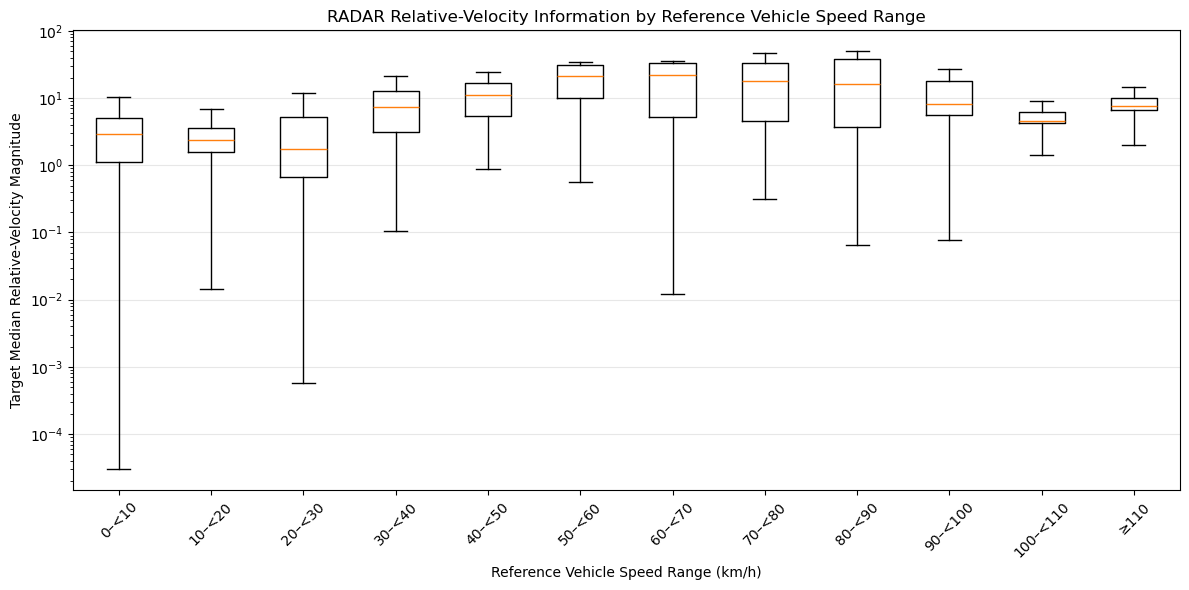

In [13]:
import matplotlib.pyplot as plt


boxplot_data = [
    radar_speed_df.loc[
        radar_speed_df["speed_range_kmh"] == speed_range,
        "median_vrel_magnitude",
    ].dropna()
    for speed_range in radar_speed_df["speed_range_kmh"].cat.categories
]


fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot(
    boxplot_data,
    labels=[
        str(label)
        for label in radar_speed_df["speed_range_kmh"].cat.categories
    ],
    showfliers=False,
)

ax.set_yscale("log")

ax.set_xlabel("Reference Vehicle Speed Range (km/h)")
ax.set_ylabel("Target Median Relative-Velocity Magnitude")

ax.set_title(
    "RADAR Relative-Velocity Information by Reference Vehicle Speed Range"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

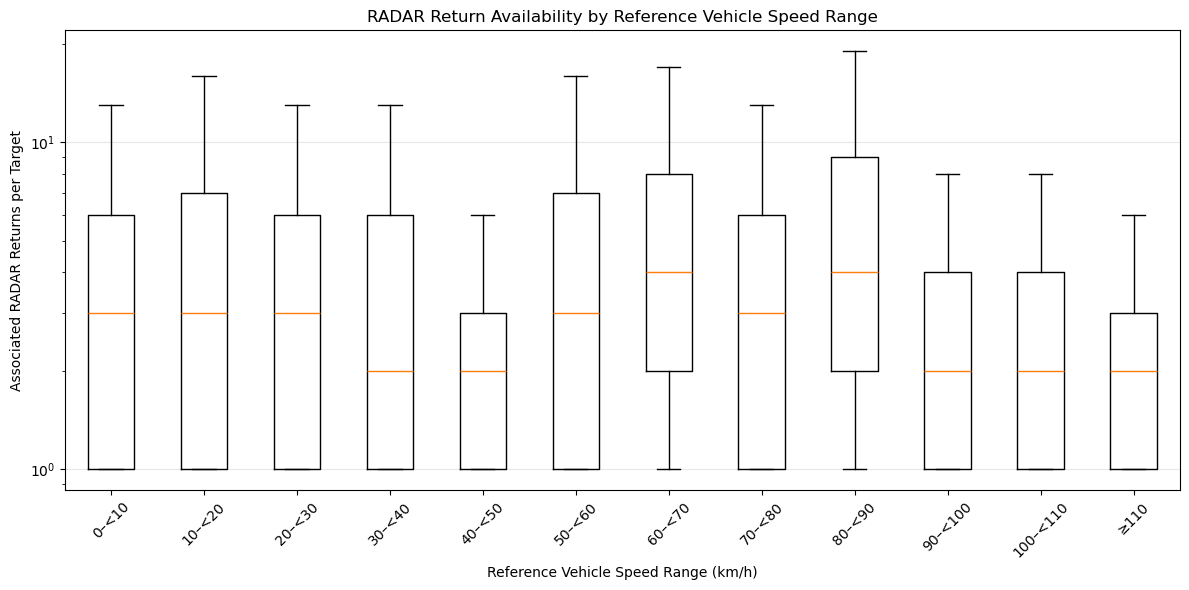

In [14]:
import matplotlib.pyplot as plt


return_count_data = [
    radar_speed_df.loc[
        radar_speed_df["speed_range_kmh"] == speed_range,
        "radar_return_count",
    ].dropna()
    for speed_range in radar_speed_df[
        "speed_range_kmh"
    ].cat.categories
]


fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot(
    return_count_data,
    labels=[
        str(label)
        for label in radar_speed_df[
            "speed_range_kmh"
        ].cat.categories
    ],
    showfliers=False,
)

ax.set_yscale("log")

ax.set_xlabel(
    "Reference Vehicle Speed Range (km/h)"
)

ax.set_ylabel(
    "Associated RADAR Returns per Target"
)

ax.set_title(
    "RADAR Return Availability by Reference Vehicle Speed Range"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

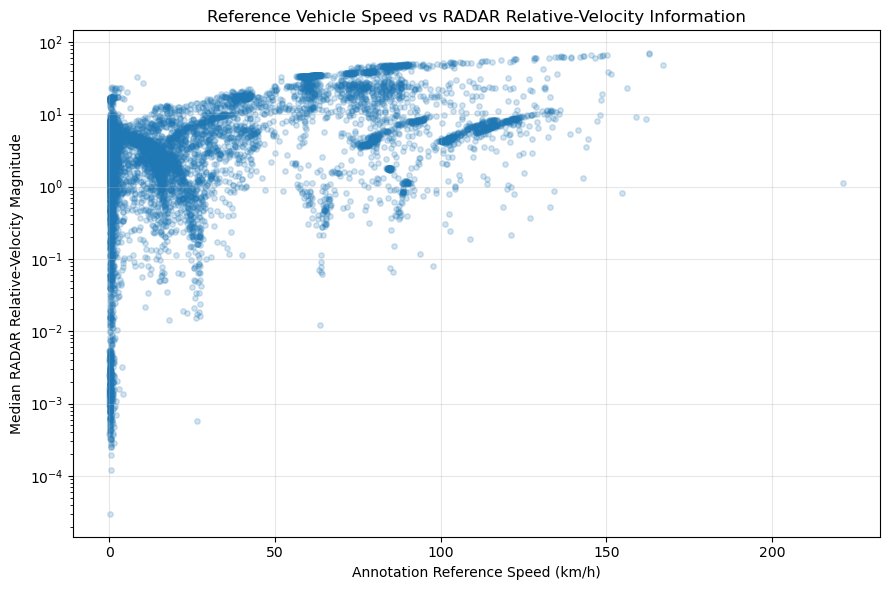

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    radar_speed_df["speed_2d_kmh"],
    radar_speed_df["median_vrel_magnitude"],
    alpha=0.2,
    s=15,
)

ax.set_yscale("log")

ax.set_xlabel(
    "Annotation Reference Speed (km/h)"
)

ax.set_ylabel(
    "Median RADAR Relative-Velocity Magnitude"
)

ax.set_title(
    "Reference Vehicle Speed vs RADAR Relative-Velocity Information"
)

ax.grid(
    alpha=0.3,
)

plt.tight_layout()
plt.show()

The distribution of target-level RADAR relative-velocity magnitude changes substantially across the reference-speed ranges, but it does not increase monotonically with absolute vehicle reference speed.

The broad within-range distributions also show that vehicles with similar annotation-derived speeds can produce substantially different RADAR relative-velocity measurements. This is consistent with `vrel_*` representing relative motion information rather than absolute target speed.

The logarithmic y-axis is used because the relative-velocity magnitudes span several orders of magnitude. No observations are removed for this visualisation.

## 6 Development and Validation of the RADAR Velocity Estimator

Several approaches were tested before selecting the final RADAR-derived 2D velocity workflow.

The raw `vrel_x`, `vrel_y`, and `vrel_z` vectors were first verified to be effectively collinear with the RADAR line-of-sight direction. They were therefore treated as signed relative radial-velocity measurements rather than full Cartesian target velocities.

Ego-motion compensation was then evaluated using both `ego_motion_chassis` and `ego_motion_cabin`. Linear and rotational compensation variants were tested using nearly stationary annotated vehicles. Cabin linear velocity produced the smallest residual radial velocity, while adding a rotational lever-arm correction did not improve the result. The current baseline therefore uses linear velocity from `ego_motion_cabin`.

Direct Cartesian velocity reconstruction from individual keyframes was also tested. Although 70.33% of RADAR target observations had a full-rank 2D system, many solutions were poorly conditioned and produced unrealistically large velocities. Combining RADAR constraints from the start and end keyframes of each annotation interval improved the median conditioning and aligned the RADAR estimate with the same interval definition used by the annotation reference velocity and LiDAR-derived velocity.

Ordinary least-squares estimation still showed a substantial error tail. Consolidating multiple returns into one constraint per RADAR sensor did not improve the reconstruction and was therefore not retained. A Huber robust least-squares estimator reduced the median and upper-quartile errors while preserving the same velocity availability.

Further analysis showed that Cartesian velocity stability is strongly related to the angular diversity of the available RADAR line-of-sight constraints. Intervals with nearly parallel viewing directions are poorly conditioned even when several RADAR returns are available. Condition number is therefore retained as a numerical stability measure for the final RADAR-derived velocity estimate.

The final baseline uses:

- cabin linear ego-motion compensation;
- RADAR returns from both endpoints of an annotation interval;
- 2D ground-plane Cartesian velocity reconstruction;
- Huber robust least squares; and
- a condition-number stability criterion.

Full 3D Cartesian velocity reconstruction was also investigated, but it showed substantially poorer numerical conditioning. The primary RADAR velocity analysis therefore uses 2D ground-plane velocity, consistent with the primary annotation and LiDAR velocity metrics.

In [16]:
from src.radar_velocity import (
    build_radar_radial_df,
    build_radar_velocity_df,
)


radar_radial_df = build_radar_radial_df(
    target_radar_points_df
)

radar_velocity_df = build_radar_velocity_df(
    radar_radial_df,
    vehicle_reference_df,
    condition_limit=20,
)


print(
    "RADAR radial returns:",
    len(radar_radial_df),
)

print(
    "RADAR velocity intervals:",
    len(radar_velocity_df),
)

display(
    radar_velocity_df.head()
)

RADAR radial returns: 52184
RADAR velocity intervals: 7706


,start_annotation_token,end_annotation_token,instance_token,category,radar_vx_mps,radar_vy_mps,radar_speed_2d_mps,condition_2d,radial_rmse_2d_mps,radar_return_count,radar_sensor_count,is_stable_2d
0,50873dd5195b47bc9544ac2821e054e0,9f0e8f997dc647bf9a0a20c679b1804d,163b7c695f7243779ef5e5f0fd844063,vehicle.car,-0.107286,-0.007742,0.107565,15.481999,0.008676,5,2,True
1,9f0e8f997dc647bf9a0a20c679b1804d,2c8422f4ac674f949fa1124dcaa1fa5e,163b7c695f7243779ef5e5f0fd844063,vehicle.car,-0.087062,-0.009281,0.087555,12.880151,0.002819,4,2,True
2,2c8422f4ac674f949fa1124dcaa1fa5e,c4d5f41838054ff581106dc5e0ed10c2,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.674699,-0.247694,0.718728,128.178415,0.003019,3,2,False
3,c4d5f41838054ff581106dc5e0ed10c2,384bb8f773d640bd851c2581d8750294,163b7c695f7243779ef5e5f0fd844063,vehicle.car,-0.072087,-0.004079,0.072202,7.304354,0.004788,8,3,True
4,384bb8f773d640bd851c2581d8750294,dab1ddee5ab1471bbc27bf7942e7d920,163b7c695f7243779ef5e5f0fd844063,vehicle.car,0.075038,-0.078659,0.108711,7.107669,0.020093,14,3,True


In [17]:
RADAR_CONDITION_LIMIT = 20


radar_stable_velocity_df = (
    radar_velocity_df[
        radar_velocity_df["condition_2d"]
        <= RADAR_CONDITION_LIMIT
    ]
    .merge(
        vehicle_reference_df[
            [
                "start_annotation_token",
                "end_annotation_token",
                "vx_mps",
                "vy_mps",
                "speed_2d_mps",
            ]
        ],
        on=[
            "start_annotation_token",
            "end_annotation_token",
        ],
        how="inner",
        validate="one_to_one",
    )
    .copy()
)


radar_stable_velocity_df[
    "radar_vx_abs_error_mps"
] = (
    radar_stable_velocity_df["radar_vx_mps"]
    - radar_stable_velocity_df["vx_mps"]
).abs()

radar_stable_velocity_df[
    "radar_vy_abs_error_mps"
] = (
    radar_stable_velocity_df["radar_vy_mps"]
    - radar_stable_velocity_df["vy_mps"]
).abs()

radar_stable_velocity_df[
    "radar_speed_2d_abs_error_mps"
] = (
    radar_stable_velocity_df["radar_speed_2d_mps"]
    - radar_stable_velocity_df["speed_2d_mps"]
).abs()


print(
    "Reference velocity intervals:",
    len(vehicle_reference_df),
)

print(
    "Raw RADAR velocity intervals:",
    len(radar_velocity_df),
)

print(
    "Stable RADAR velocity intervals:",
    len(radar_stable_velocity_df),
)

print(
    "Raw RADAR velocity availability (%):",
    round(
        len(radar_velocity_df)
        / len(vehicle_reference_df)
        * 100,
        2,
    ),
)

print(
    "Stable RADAR velocity availability (%):",
    round(
        len(radar_stable_velocity_df)
        / len(vehicle_reference_df)
        * 100,
        2,
    ),
)


print("\nStable RADAR 2D speed error:")

display(
    radar_stable_velocity_df[
        "radar_speed_2d_abs_error_mps"
    ].describe()
)

Reference velocity intervals: 15743
Raw RADAR velocity intervals: 7706
Stable RADAR velocity intervals: 3016
Raw RADAR velocity availability (%): 48.95
Stable RADAR velocity availability (%): 19.16

Stable RADAR 2D speed error:


count    3016.000000
mean        7.428636
std        31.561879
min         0.000113
25%         0.089592
50%         0.276923
75%         1.208074
max       420.550415
Name: radar_speed_2d_abs_error_mps, dtype: float64

Using a condition-number limit of 20, 3,016 of the 15,743 vehicle reference intervals provide a numerically stable RADAR-derived 2D velocity estimate, corresponding to a velocity availability of 19.16%.

The median absolute 2D speed error is 0.277 m/s. However, the error distribution remains strongly right-skewed, indicating that a small number of intervals still produce large Cartesian velocity errors despite the geometry-based stability criterion. Median and percentile statistics are therefore interpreted alongside the mean error.

In [18]:
reference_speed_df = vehicle_reference_df.copy()

reference_speed_df["speed_2d_kmh"] = (
    reference_speed_df["speed_2d_mps"] * 3.6
)

reference_speed_df["speed_range_kmh"] = pd.cut(
    reference_speed_df["speed_2d_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
    include_lowest=True,
)


radar_stable_velocity_df["speed_2d_kmh"] = (
    radar_stable_velocity_df["speed_2d_mps"] * 3.6
)

radar_stable_velocity_df["speed_range_kmh"] = pd.cut(
    radar_stable_velocity_df["speed_2d_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
    include_lowest=True,
)


reference_counts = (
    reference_speed_df
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .size()
    .rename("Reference Intervals")
)

radar_velocity_summary = (
    radar_stable_velocity_df
    .groupby(
        "speed_range_kmh",
        observed=False,
    )
    .agg(
        RADAR_Velocity_Intervals=(
            "radar_speed_2d_mps",
            "size",
        ),
        Median_Abs_Error_mps=(
            "radar_speed_2d_abs_error_mps",
            "median",
        ),
        Mean_Abs_Error_mps=(
            "radar_speed_2d_abs_error_mps",
            "mean",
        ),
        P75_Abs_Error_mps=(
            "radar_speed_2d_abs_error_mps",
            lambda x: x.quantile(0.75),
        ),
        P95_Abs_Error_mps=(
            "radar_speed_2d_abs_error_mps",
            lambda x: x.quantile(0.95),
        ),
    )
)


radar_velocity_speed_summary = pd.concat(
    [
        reference_counts,
        radar_velocity_summary,
    ],
    axis=1,
)


radar_velocity_speed_summary[
    "Velocity Availability (%)"
] = (
    radar_velocity_speed_summary[
        "RADAR_Velocity_Intervals"
    ]
    / radar_velocity_speed_summary[
        "Reference Intervals"
    ]
    * 100
)


radar_velocity_speed_summary = (
    radar_velocity_speed_summary[
        [
            "Reference Intervals",
            "RADAR_Velocity_Intervals",
            "Velocity Availability (%)",
            "Median_Abs_Error_mps",
            "Mean_Abs_Error_mps",
            "P75_Abs_Error_mps",
            "P95_Abs_Error_mps",
        ]
    ]
    .round(3)
)


display(
    radar_velocity_speed_summary
)

,Reference Intervals,RADAR_Velocity_Intervals,Velocity Availability (%),Median_Abs_Error_mps,Mean_Abs_Error_mps,P75_Abs_Error_mps,P95_Abs_Error_mps
speed_range_kmh,,,,,,,
0–<10,6870,1594,23.202,0.160,0.905,0.406,2.843
10–<20,2028,309,15.237,0.177,0.732,0.422,3.227
20–<30,1211,200,16.515,0.433,1.457,1.693,5.448
30–<40,799,145,18.148,1.294,3.463,5.203,9.582
40–<50,510,37,7.255,0.363,1.346,0.675,7.961
50–<60,424,62,14.623,0.829,18.354,15.925,112.557
60–<70,542,92,16.974,2.773,31.809,31.545,140.622
70–<80,823,175,21.264,1.222,25.084,17.390,141.689
80–<90,797,183,22.961,6.784,31.281,28.913,126.168


Stable RADAR-derived velocity availability varies substantially across the reference-speed ranges and does not follow a monotonic relationship with vehicle speed.

Typical RADAR speed errors are relatively small in the lower-speed ranges, but larger errors and substantially heavier error tails appear in several medium- and high-speed ranges. The difference between the median and mean errors shows that the RADAR-derived Cartesian velocity estimates remain strongly right-skewed even after robust estimation and geometry-based stability filtering.

Some speed ranges contain relatively few stable RADAR velocity intervals, so their error statistics should be interpreted cautiously. These results describe performance under different reference-speed conditions but do not establish vehicle speed as the direct cause of the observed error differences.

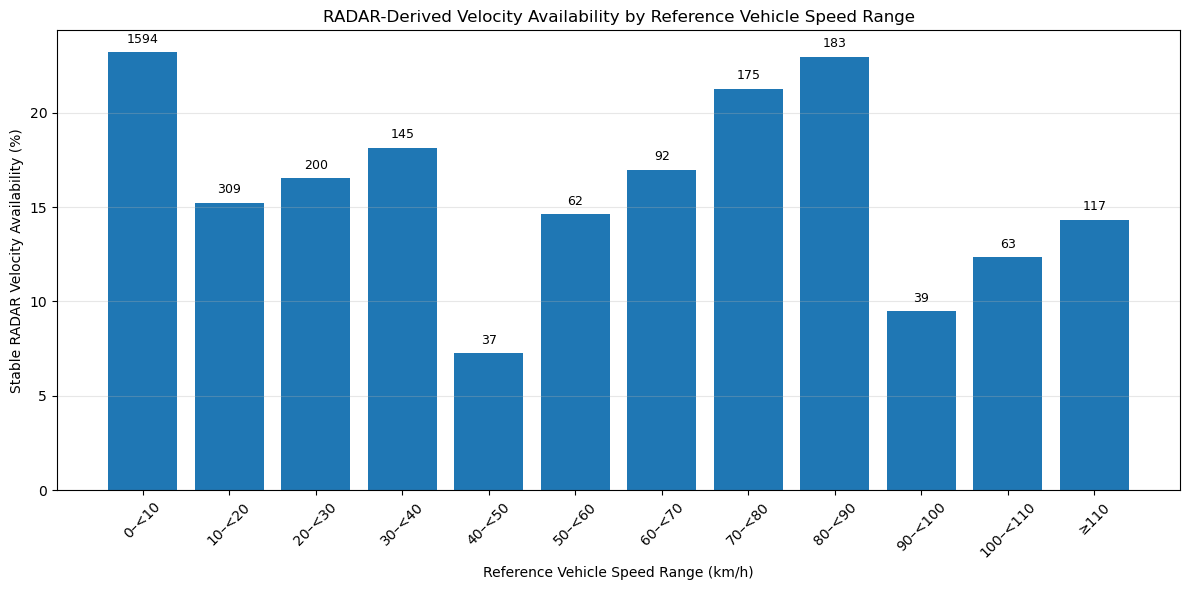

In [19]:
import matplotlib.pyplot as plt


plot_data = radar_velocity_speed_summary.reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    plot_data["speed_range_kmh"].astype(str),
    plot_data["Velocity Availability (%)"],
)

ax.set_xlabel(
    "Reference Vehicle Speed Range (km/h)"
)

ax.set_ylabel(
    "Stable RADAR Velocity Availability (%)"
)

ax.set_title(
    "RADAR-Derived Velocity Availability by Reference Vehicle Speed Range"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

for i, row in plot_data.iterrows():
    ax.text(
        i,
        row["Velocity Availability (%)"] + 0.5,
        str(
            int(
                row["RADAR_Velocity_Intervals"]
            )
        ),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

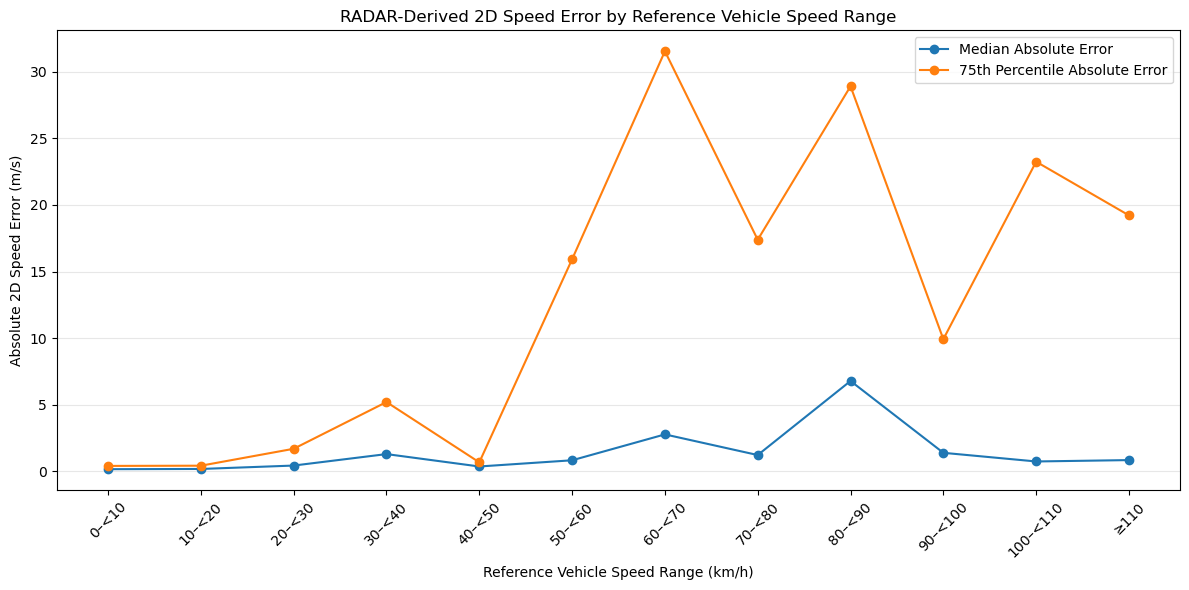

In [20]:
import numpy as np

plot_data = radar_velocity_speed_summary.reset_index()

x = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    x,
    plot_data["Median_Abs_Error_mps"],
    marker="o",
    label="Median Absolute Error",
)

ax.plot(
    x,
    plot_data["P75_Abs_Error_mps"],
    marker="o",
    label="75th Percentile Absolute Error",
)

ax.set_xticks(x)

ax.set_xticklabels(
    plot_data["speed_range_kmh"].astype(str),
    rotation=45,
)

ax.set_xlabel(
    "Reference Vehicle Speed Range (km/h)"
)

ax.set_ylabel(
    "Absolute 2D Speed Error (m/s)"
)

ax.set_title(
    "RADAR-Derived 2D Speed Error by Reference Vehicle Speed Range"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

The RADAR-derived 2D speed error varies substantially across the reference-speed ranges.

Median errors remain relatively small in several ranges, while the 75th-percentile error increases sharply in some medium- and high-speed conditions. This indicates that the RADAR-derived velocity error distribution becomes substantially wider for some operating conditions, rather than following a simple monotonic relationship with vehicle speed.

The variation should not be interpreted as being caused by vehicle speed alone, since RADAR velocity reconstruction is also affected by line-of-sight geometry, available RADAR returns, and numerical conditioning.

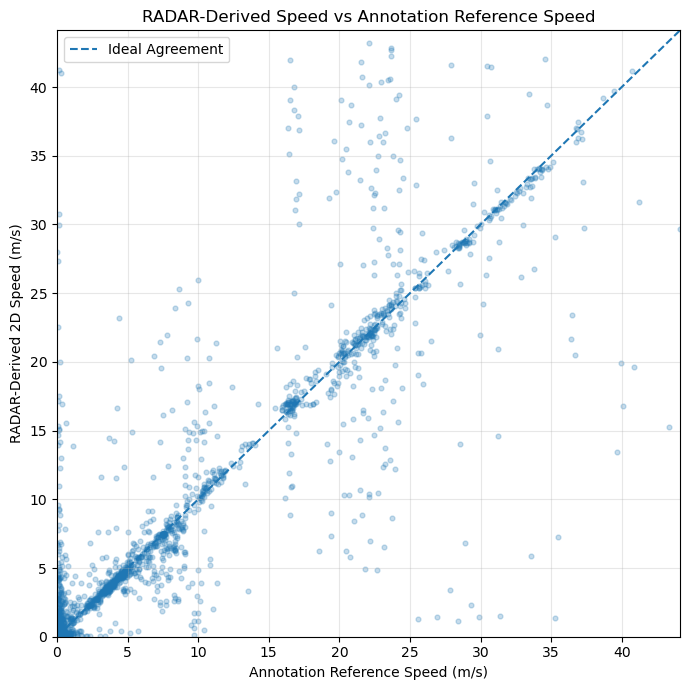

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    radar_stable_velocity_df["speed_2d_mps"],
    radar_stable_velocity_df["radar_speed_2d_mps"],
    alpha=0.25,
    s=12,
)

plot_limit = (
    radar_stable_velocity_df["speed_2d_mps"].max()
)

ax.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    label="Ideal Agreement",
)

ax.set_xlim(0, plot_limit)
ax.set_ylim(0, plot_limit)

ax.set_xlabel(
    "Annotation Reference Speed (m/s)"
)

ax.set_ylabel(
    "RADAR-Derived 2D Speed (m/s)"
)

ax.set_title(
    "RADAR-Derived Speed vs Annotation Reference Speed"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Most stable RADAR-derived 2D velocity estimates follow the annotation reference-speed trend, particularly in the lower and moderate speed ranges.

However, a subset of intervals still shows substantial deviation from ideal agreement. These observations remain included in the numerical error statistics and reflect the remaining limitations of Cartesian velocity reconstruction from RADAR radial measurements.

The displayed axes focus on the annotation reference-speed range for readability; RADAR estimates outside this range are not removed from the analysis.

## 7. Summary and Limitations

This notebook established a reusable workflow for analysing target-associated RADAR velocity information in TruckScenes.

The main findings are:

- All inspected RADAR channels provide point-level `vrel_x`, `vrel_y`, and `vrel_z` measurements.

- RADAR returns can be associated with annotated targets by transforming annotation boxes from the global frame into each RADAR sensor frame. The association method was validated against `num_radar_pts`, with exact agreement for the tested keyframe sample.

- Across the keyframe observations, 52,184 RADAR returns were associated with 9,588 target-vehicle annotations from 639 unique vehicle instances.

- A target with RADAR information contains a median of three associated returns, showing that target-level RADAR information is relatively sparse.

- 9,280 target-level RADAR observations could be aligned with annotation-derived reference-velocity intervals. All unmatched observations corresponded to the final annotation of an object trajectory.

- RADAR information availability varies across the reference-speed ranges and does not change monotonically with vehicle speed.

- The original `vrel_*` measurements represent relative radial motion rather than absolute target velocity. Their magnitude therefore varies substantially within and between reference-speed ranges and is not interpreted as absolute target speed.

- Ego-motion compensation using the linear velocity from `ego_motion_cabin` was used to convert the RADAR relative radial measurements into ego-compensated radial-velocity constraints.

- Combining RADAR constraints from both endpoints of an annotation interval produced 7,706 full-rank 2D velocity intervals, corresponding to a raw RADAR velocity availability of 48.95%.

- A Huber robust least-squares estimator was used for 2D Cartesian velocity reconstruction. After applying the validated condition-number limit of 20, 3,016 intervals remained as the stable RADAR velocity baseline, corresponding to an availability of 19.16%.

- The stable RADAR-derived 2D speed estimates have a median absolute error of approximately 0.277 m/s relative to the annotation-derived reference velocity. However, the error distribution remains strongly right-skewed, with some intervals producing substantially larger errors.

- RADAR velocity error varies substantially across the reference-speed ranges and does not follow a simple monotonic relationship with vehicle speed.

The current analysis has several limitations.

Only keyframe RADAR observations are used for target-level analysis. Intermediate RADAR sweeps are not included, so the results do not represent the full RADAR observation frequency available in TruckScenes.

The final RADAR Cartesian velocity baseline is limited to 2D ground-plane velocity. A 3D reconstruction was investigated during estimator development, but its numerical conditioning was substantially poorer and it was not retained as a validated baseline.

The condition-number limit of 20 is a project-specific numerical-stability criterion selected from the estimator-development analysis. It is not an official TruckScenes threshold and does not guarantee that every retained velocity estimate is accurate.

Although robust estimation reduces the influence of inconsistent radial measurements, a long tail of large Cartesian velocity errors remains. These errors are retained in the reported statistics rather than removed using an additional error-based filter.

The current information-availability metrics describe whether an annotated target receives RADAR returns and how many usable returns are available, while the velocity-availability metric describes whether those measurements can support a stable 2D Cartesian velocity estimate. These measures do not by themselves define the final RADAR–LiDAR efficiency comparison, which will require equivalent observation conditions and consistent comparison metrics across both sensor modalities.

In [22]:
from pathlib import Path

RESULTS_ROOT = Path("../results/validated")

target_radar_df.to_pickle(
    RESULTS_ROOT / "target_radar_df.pkl"
)

radar_stable_velocity_df.to_pickle(
    RESULTS_ROOT / "radar_velocity_df.pkl"
)

print("Saved target_radar_df.pkl")
print("RADAR target rows:", len(target_radar_df))

print("Saved radar_velocity_df.pkl")
print("Stable RADAR velocity intervals:", len(radar_stable_velocity_df))

Saved target_radar_df.pkl
RADAR target rows: 9588
Saved radar_velocity_df.pkl
Stable RADAR velocity intervals: 3016
